# Business Objective #
**To predict customers likely to churn, identify key factors influencing churn, and help the telecom company take proactive retention actions** 
**to reduce customer loss and improve revenue.**

# 1. Importing the dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, cross_validate



# 2. Data Loading and Understanding

In [2]:
df = pd.read_csv(r"D:\Mine\data_set\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df = df.drop(columns=['customerID'])

In [8]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.columns = df.columns.str.lower()

In [10]:
def uniques_values(df):
    for col in df.columns:
        print(f'unique values in {col} {df[col].unique()}')
        print('_'*110)

uniques_values(df)

unique values in gender ['Female' 'Male']
______________________________________________________________________________________________________________
unique values in seniorcitizen [0 1]
______________________________________________________________________________________________________________
unique values in partner ['Yes' 'No']
______________________________________________________________________________________________________________
unique values in dependents ['No' 'Yes']
______________________________________________________________________________________________________________
unique values in tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
______________________________________________________________________________________________________________
unique values in phoneservice ['No' 'Ye

In [11]:
df.isnull().sum()

gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [12]:
for col in ['monthlycharges','totalcharges']:
    cleaned_series = df[col].astype(str).str.strip()
    df[col] = pd.to_numeric(cleaned_series, errors='coerce')


In [13]:
df.isnull().sum()

gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

In [14]:
df['totalcharges'] = df['totalcharges'].fillna(df['totalcharges'].mean())

In [15]:
df.isnull().sum()

gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

**Insights:**
1. Customer ID removed as it not required for modelling
2. Missing value in TotalCharges fill with TotalCharges mean
3. Target variable is imbalance

# 3. Exploratory Data Analysis #

In [16]:
nums_columns = ['tenure','monthlycharges','totalcharges']

for col in ['tenure', 'monthlycharges', 'totalcharges']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
cat_columns = df.drop(nums_columns, axis = 1).columns.tolist()

**Numerical Features - Analysis** ***(Understand the distribution of teh numerical features)***

In [17]:
def plot_histogram(df, column_name):

    plt.figure(figsize=(5,5))
    sns.displot(data=df, x=column_name, kind='hist', kde=True)
    plt.title(f'Distribution of {column_name}')

    col_mean = df[column_name].mean()
    col_median = df[column_name].median()

    plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
    plt.axvline(col_median, color="green", linestyle="-", label="median")

    plt.legend()

    plt.show()

<Figure size 500x500 with 0 Axes>

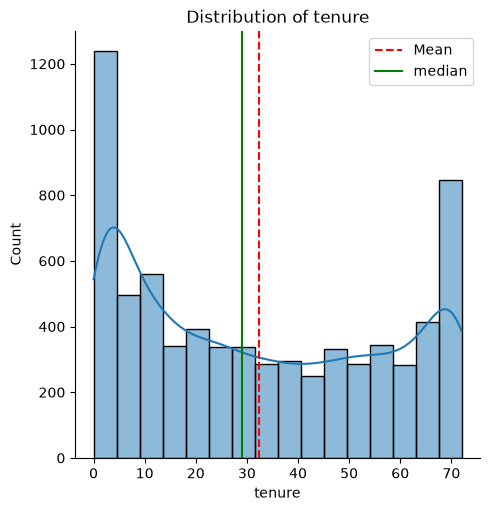

In [18]:
plot_histogram(df, 'tenure')

<Figure size 500x500 with 0 Axes>

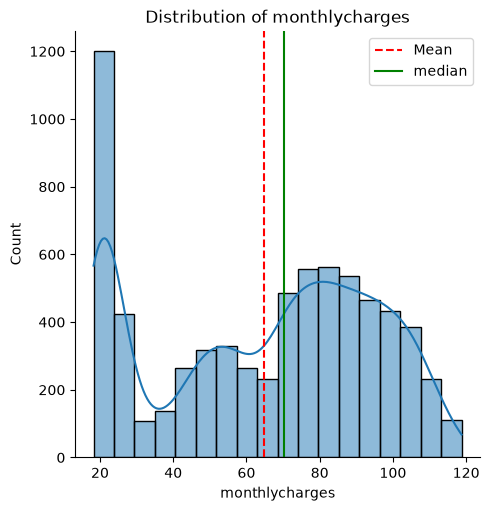

In [19]:
plot_histogram(df, 'monthlycharges')

<Figure size 500x500 with 0 Axes>

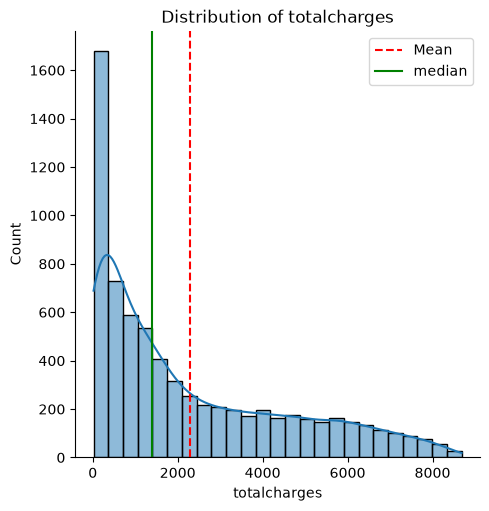

In [20]:
plot_histogram(df, 'totalcharges')

In [21]:
def box_plots(df, column_name):
    plt.figure(figsize=(5,5))
    plt.boxplot(x=df[column_name])
    plt.title(f'Box plot for {column_name}')
    plt.xlabel(column_name)
    plt.show()

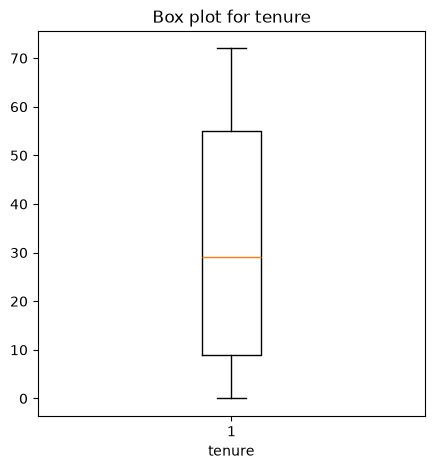

In [22]:
box_plots(df, 'tenure')

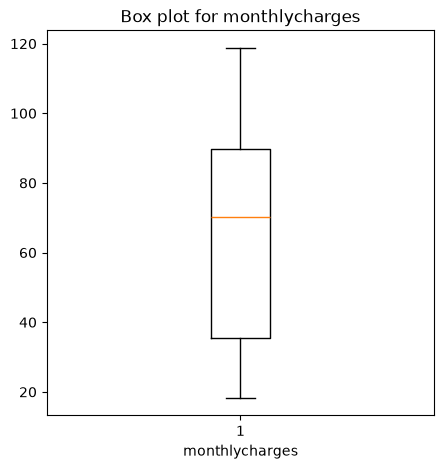

In [23]:
box_plots(df, 'monthlycharges')

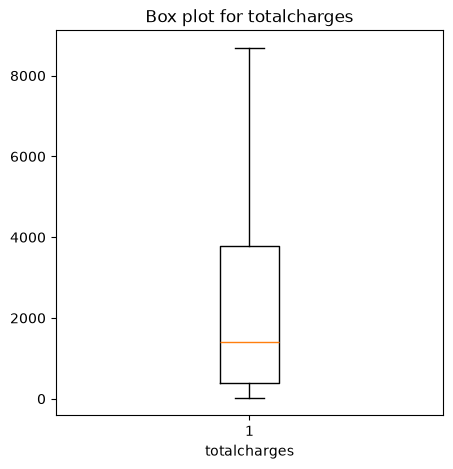

In [24]:
box_plots(df, 'totalcharges')

<Axes: >

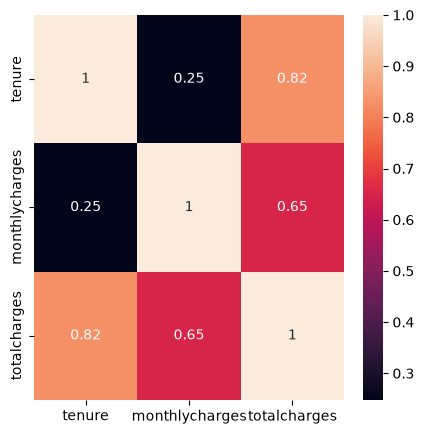

In [25]:
plt.figure(figsize=(5,5))
sns.heatmap(df[nums_columns].corr(), annot= True)

**Key Numerical Insights**

***1. Customer Lifespan (Tenure)***
* **Two Main Groups:** Most customers are either brand new with very low tenure, or highly loyal and stay for several years.
* **No Extremes:** The box plot confirms there are no weird or unusual outlier values in this data.

***2. Monthly Bills (Monthly Charges)***
* **The Sweet Spot:** Most customers pay between **$35 and $90** per month, with the middle-ground customer paying around **$70**.
* **Wide Variety:** There are no major outliers, but there is a wide gap between the cheapest and most expensive plans.

***3. Total Money Spent (Total Charges)***
* **Right-Skewed Distribution:** The vast majority of customers have lower total lifetime charges. 
* **Long-Term Accumulation:** A small group of highly loyal, long-term customers have accumulated very high total charges, stretching the data out.


***Correlation***

* ****Tenure vs. Total Charges (Strong: 0.82):** This is your strongest relationship. It makes perfect sense: the longer a customer stays with the company, the more total money they spend over time.
* **Monthly Charges vs. Total Charges (Moderate: 0.65):** Customers with higher monthly bills naturally tend to rack up higher total lifetime bills.
* **Tenure vs. Monthly Charges (Weak: 0.25):** There is almost no link here. This means a customer's monthly bill amount does not dictate how many months they choose to stay.


**Categorical features - Analysis**

In [26]:
cat_columns

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'churn']

<Figure size 500x500 with 0 Axes>

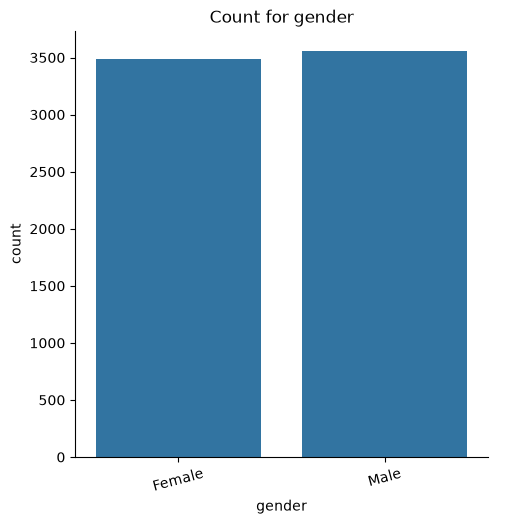

<Figure size 500x500 with 0 Axes>

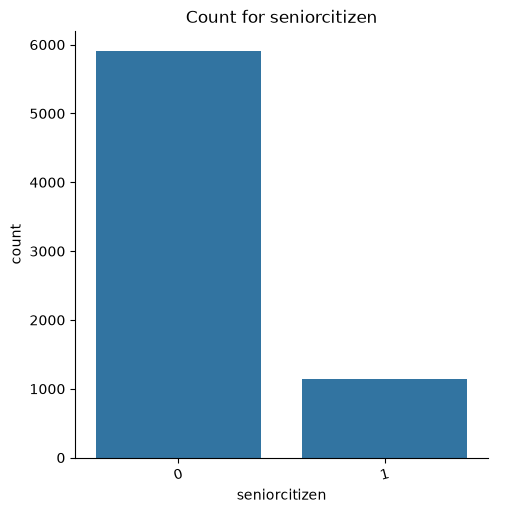

<Figure size 500x500 with 0 Axes>

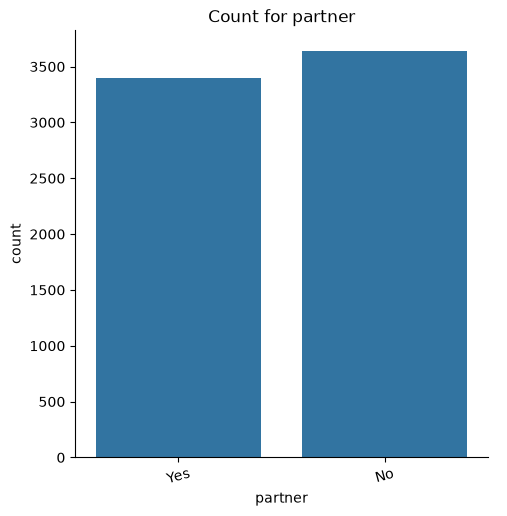

<Figure size 500x500 with 0 Axes>

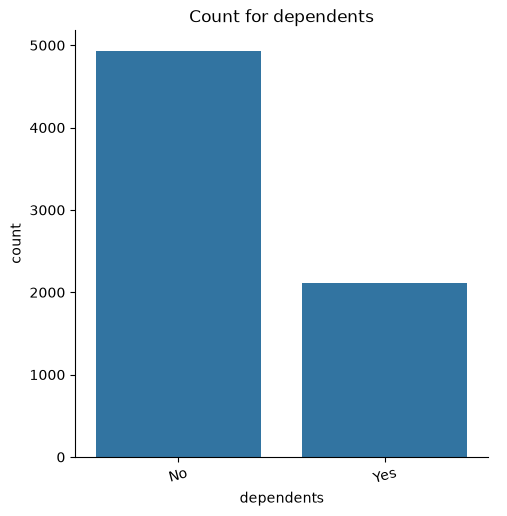

<Figure size 500x500 with 0 Axes>

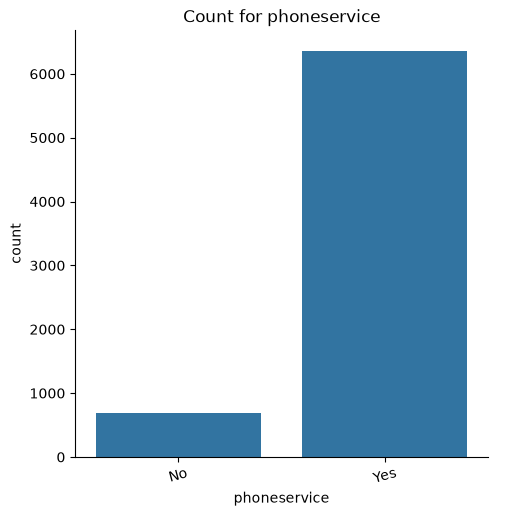

<Figure size 500x500 with 0 Axes>

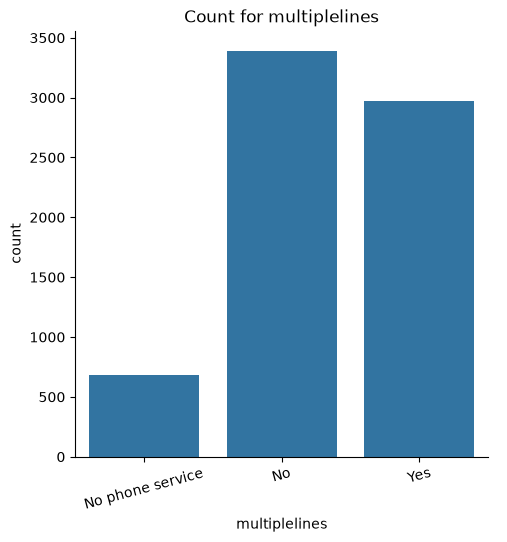

<Figure size 500x500 with 0 Axes>

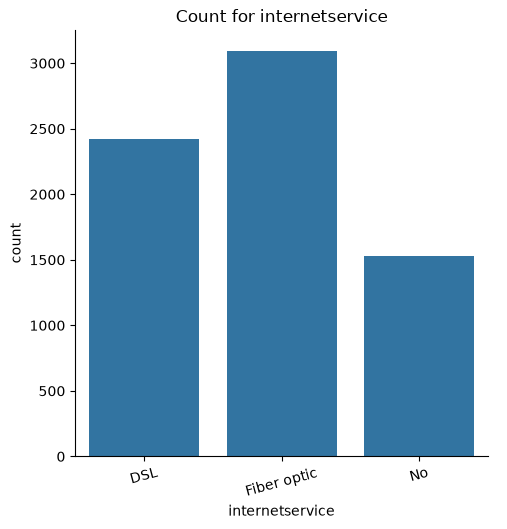

<Figure size 500x500 with 0 Axes>

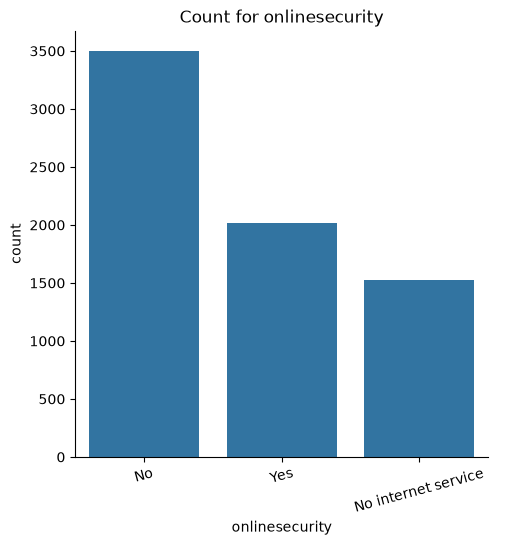

<Figure size 500x500 with 0 Axes>

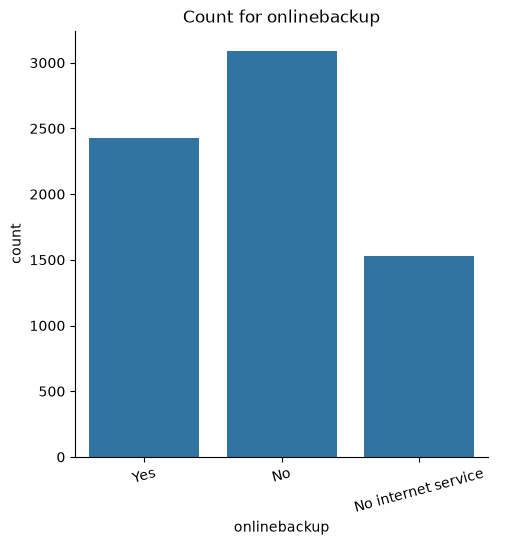

<Figure size 500x500 with 0 Axes>

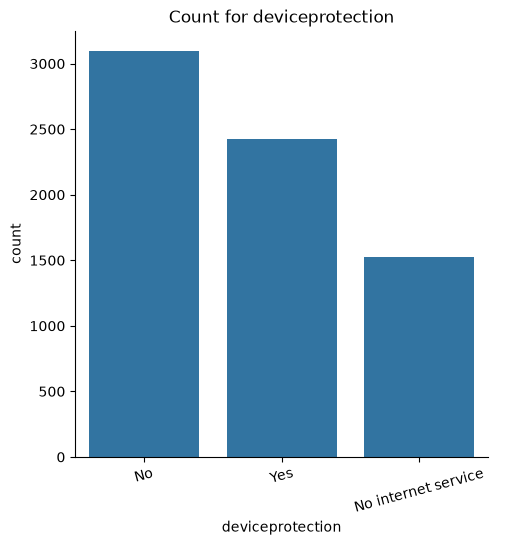

<Figure size 500x500 with 0 Axes>

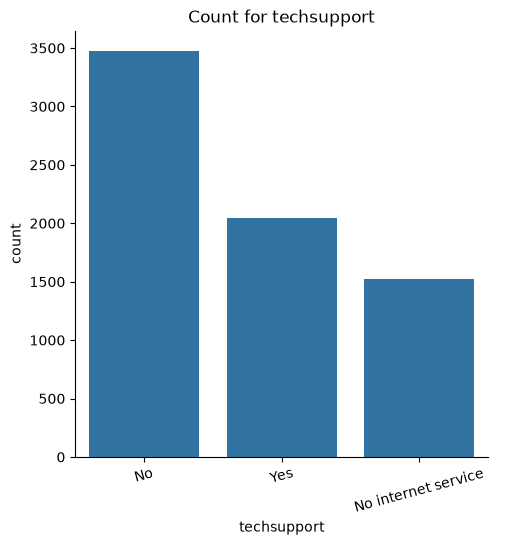

<Figure size 500x500 with 0 Axes>

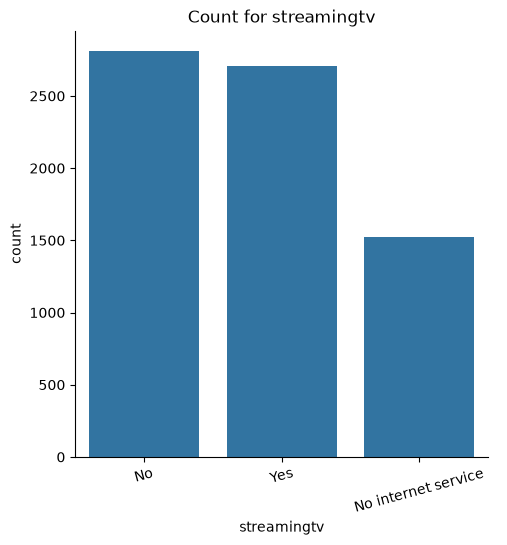

<Figure size 500x500 with 0 Axes>

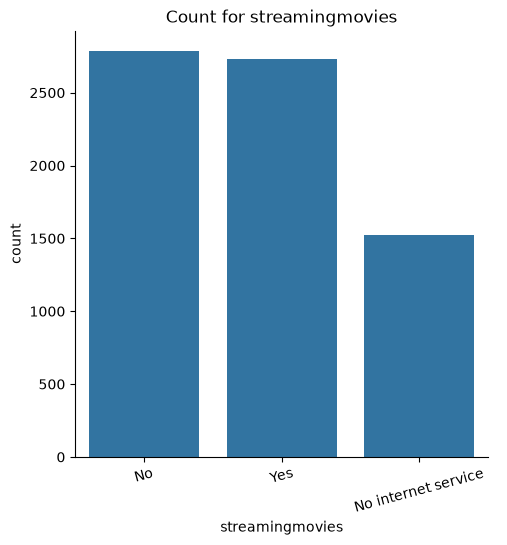

<Figure size 500x500 with 0 Axes>

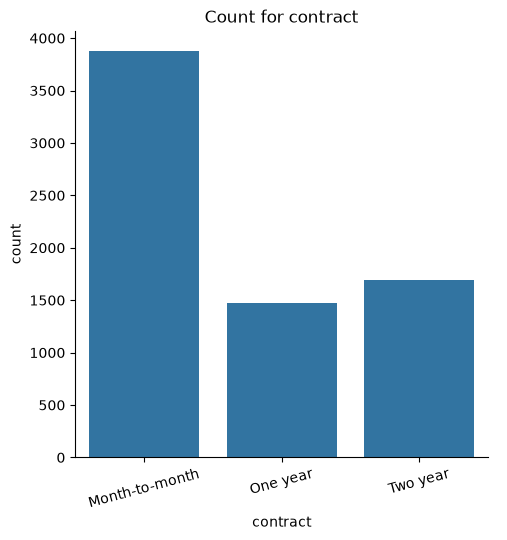

<Figure size 500x500 with 0 Axes>

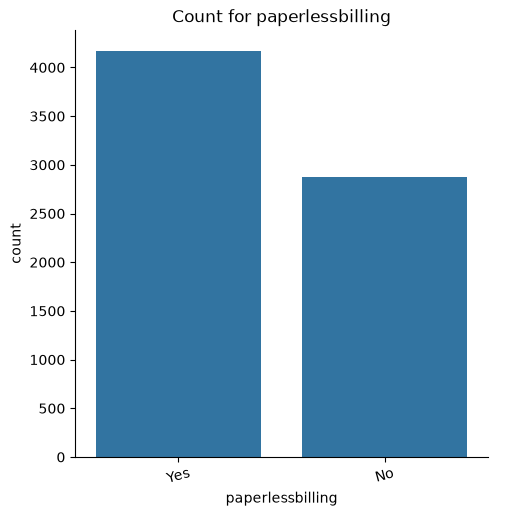

<Figure size 500x500 with 0 Axes>

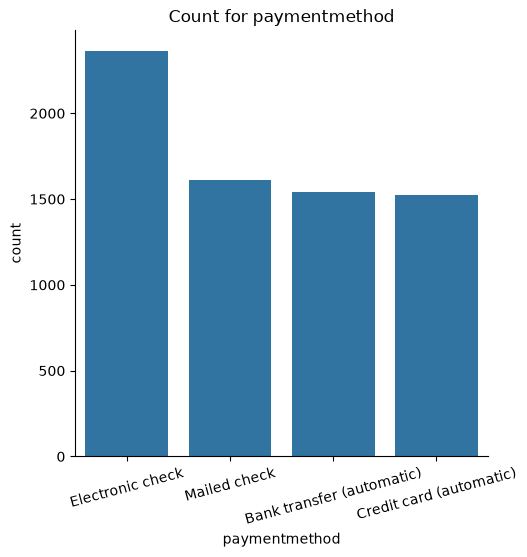

<Figure size 500x500 with 0 Axes>

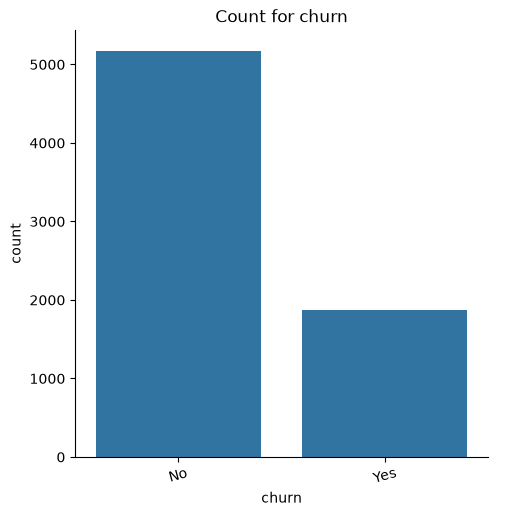

In [27]:
def count_plot(df):
    for column in cat_columns:
        plt.figure(figsize=(5,5))
        sns.catplot(data=df, x=column, kind='count')
        plt.title(f'Count for {column}')
        plt.xticks(rotation=15)
        plt.show()
        
count_plot(df)

In [28]:
def categorical_correlation(df, target_col='churn', alpha=0.05):
    
    print(f'Running Chi-Square Test against target: {target_col}\n')

    for col in cat_columns:
        if col==target_col:
            continue

        contingency_table = pd.crosstab(df[col],df[target_col])
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        print(f"Chi-Square Statistic: {chi2:.5f}")
        print(f"P-value: {p:.5f}")
        print(f'Degree of freedom {dof}')

        if p < 0.05:
            print(f"Statistically Significant: {col} and {target_col} are related to each other at {1-alpha}% confidence level\n")
        else:
            print(f"Not Significant: {col} and {target_col} are independent variable at {1-alpha}% confidence level\n")
            
        


In [29]:
categorical_correlation(df)

Running Chi-Square Test against target: churn

Chi-Square Statistic: 0.48408
P-value: 0.48658
Degree of freedom 1
Not Significant: gender and churn are independent variable at 0.95% confidence level

Chi-Square Statistic: 159.42630
P-value: 0.00000
Degree of freedom 1
Statistically Significant: seniorcitizen and churn are related to each other at 0.95% confidence level

Chi-Square Statistic: 158.73338
P-value: 0.00000
Degree of freedom 1
Statistically Significant: partner and churn are related to each other at 0.95% confidence level

Chi-Square Statistic: 189.12925
P-value: 0.00000
Degree of freedom 1
Statistically Significant: dependents and churn are related to each other at 0.95% confidence level

Chi-Square Statistic: 0.91503
P-value: 0.33878
Degree of freedom 1
Not Significant: phoneservice and churn are independent variable at 0.95% confidence level

Chi-Square Statistic: 11.33044
P-value: 0.00346
Degree of freedom 2
Statistically Significant: multiplelines and churn are related 

**Insights**

1. **SeniorCitizen:** Most customers are not senior citizens, with only a small portion being senior citizens.

2. **PhoneService:** The majority of customers have phone service.

3. **MultipleLines:** Most customers either have one line or multiple lines, while few have no phone service.

4. **InternetService:** Fiber optic is the most common internet service, followed by DSL.

5. **OnlineSecurity:** More customers do not have online security than those who have it.

6. **Contract:** Month-to-month contracts are the most common, while one- and two-year contracts are less common.

7. **Churn:** Most customers stay with the company, while a smaller proportion of customers churn.

**Chi-Square Test Insights**

- **Gender and PhoneService** are not significantly related to churn, suggesting they have little statistical association with customer churn.
- Most other categorical features, especially **Contract, OnlineSecurity, TechSupport, InternetService, and PaymentMethod**, show a significant relationship with churn and may be important predictors.

###  Churn vs Numrical feature

In [30]:
def box_plot(numrical_columns, cat_columns='churn'):
    for col in numrical_columns:
        
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[cat_columns],y=df[col])
        plt.show()
    

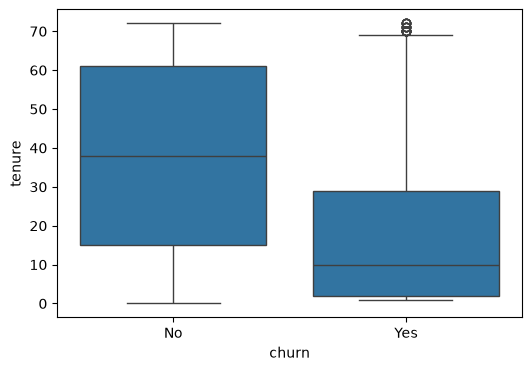

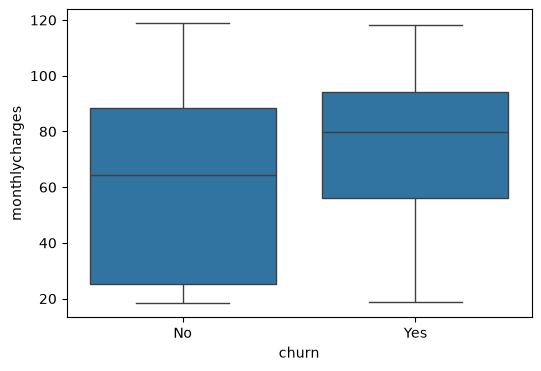

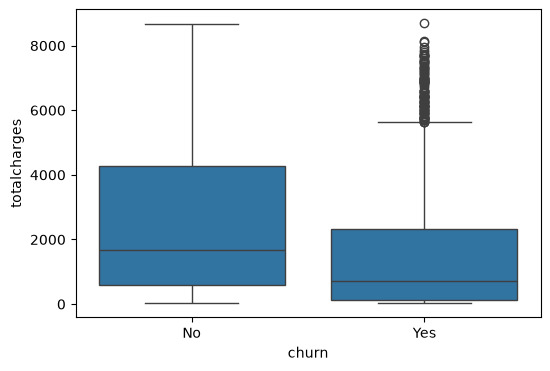

In [31]:
box_plot(nums_columns)

## Churn vs Numerical Features Insights

1. **Tenure:** Customers who churn have **lower tenure** than customers who stay, suggesting newer customers are more likely to churn.

2. **Monthly Charges:** Churned customers generally have **higher monthly charges** than customers who stay.

3. **Total Charges:** Customers who stay tend to have **higher total charges**, mainly because they have longer tenure.

## Key EDA Insights

1. **Dataset:** The dataset contains 7,043 customers and 21 features, with no missing values.

2. **Tenure:** Customers who churn generally have **lower tenure**, indicating that newer customers are more likely to leave.

3. **Monthly Charges:** Churned customers generally have **higher monthly charges** than customers who stay.

4. **Total Charges:** Customers who stay tend to have **higher total charges**, mainly due to their longer tenure.

5. **SeniorCitizen:** Most customers are not senior citizens, while senior citizens represent a smaller portion of the customer base.

6. **PhoneService:** The majority of customers have phone service.

7. **MultipleLines:** Most customers either have a single line or multiple lines, while few have no phone service.

8. **InternetService:** Fiber optic is the most common internet service, followed by DSL.

9. **OnlineSecurity:** More customers do not have online security than those who have it.

10. **Contract:** Month-to-month contracts are the most common, which may contribute to higher customer churn.

11. **Churn:** Most customers stay with the company, while a smaller proportion churn, making the target variable imbalanced.

12. **Correlation:** Tenure and total charges have a strong positive correlation (0.82), while monthly charges and total charges have a moderate positive correlation (0.65).

13. **Chi-Square Test:** Gender and PhoneService show no significant relationship with churn, while most other categorical features have a significant association with churn.

14. **Important Features:** Contract, OnlineSecurity, TechSupport, InternetService, and PaymentMethod show strong relationships with churn and may be useful predictors.

In [32]:
df.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [33]:
X = df.drop(columns=["churn",'gender','phoneservice'])
y = df["churn"].map({"No": 0, "Yes": 1})

In [34]:

nominal_cols = [
    "partner",
    "dependents",
    "multiplelines",
    "internetservice",
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies",
    "paperlessbilling",
    "paymentmethod"
]

ordinal_cols = ["contract"]


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("ordinal", OrdinalEncoder(categories=[["Month-to-month", "One year", "Two year"]]), ordinal_cols), 
        ("numeric", StandardScaler(), nums_columns)], 
    remainder="passthrough")

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [37]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nominal', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` 

In [38]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [39]:
print(X_train.shape)
print(X_train_processed.shape)

(5634, 17)
(5634, 39)


## Data Preprocessing

- **Separate features and target:** We use all columns except `churn` as input features (`X`) and convert the target `churn` into numerical values, where `No = 0` and `Yes = 1`.

- **Categorical features:** Nominal categorical columns are converted into numerical values using **One-Hot Encoding**. The `contract` column is encoded using **Ordinal Encoding** because it has an order from month-to-month to two-year contracts.

- **Numerical features:** Numerical columns such as `tenure`, `monthlycharges`, and `totalcharges` are standardized using **StandardScaler** so that they are on a similar scale.

- **Train-Test Split:** The dataset is divided into **80% training data and 20% testing data**. `stratify=y` keeps the same churn ratio in both datasets.

- **Fit and Transform:** The preprocessor is fitted only on the training data to avoid data leakage. It is then used to transform both training and testing data.

- **Final Data:** The original categorical and numerical features are converted into a numerical format that can be used by machine learning models.

In [40]:
log_reg = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, min_samples_split=2, n_jobs=-1,class_weight="balanced")

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric="logloss")

In [41]:
log_reg.fit(X_train_processed, y_train)

rf.fit(X_train_processed, y_train)

xgb.fit(X_train_processed, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [42]:
y_pred_lr = log_reg.predict(X_test_processed)
y_pred_rf = rf.predict(X_test_processed)
y_pred_xgb = xgb.predict(X_test_processed)

In [43]:
y_prob_lr = log_reg.predict_proba(X_test_processed)[:, 1]
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test_processed)[:, 1]

In [44]:


models = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "XGBoost": (y_pred_xgb, y_prob_xgb)
}
for name, (pred, prob) in models.items():

    print(f"\n{name}")
    print("Accuracy ", accuracy_score(y_test, pred))
    print("Precision ", precision_score(y_test, pred))
    print("Recall ", recall_score(y_test, pred))
    print("F1 Score", f1_score(y_test, pred))
    print("ROC-AUC", roc_auc_score(y_test, prob),'\n','-'*80)
    print('ClassificationReport',classification_report(y_test, pred))



Logistic Regression
Accuracy  0.7366926898509581
Precision  0.5025728987993139
Recall  0.7834224598930482
F1 Score 0.6123301985370951
ROC-AUC 0.8415433103412644 
 --------------------------------------------------------------------------------
ClassificationReport               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Random Forest
Accuracy  0.7551454932576295
Precision  0.5274102079395085
Recall  0.7459893048128342
F1 Score 0.6179401993355482
ROC-AUC 0.8368157276085665 
 --------------------------------------------------------------------------------
ClassificationReport               precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75     

In [45]:

y_train_pred_lr = log_reg.predict(X_train_processed)
y_train_pred_rf = rf.predict(X_train_processed)
y_train_pred_xgb = xgb.predict(X_train_processed)

y_train_prob_lr = log_reg.predict_proba(X_train_processed)[:, 1]
y_train_prob_rf = rf.predict_proba(X_train_processed)[:, 1]
y_train_prob_xgb = xgb.predict_proba(X_train_processed)[:, 1]


train_models = {
    "Logistic Regression": (y_train_pred_lr, y_train_prob_lr),
    "Random Forest": (y_train_pred_rf, y_train_prob_rf),
    "XGBoost": (y_train_pred_xgb, y_train_prob_xgb)
}

for name, (pred, prob) in train_models.items():

    print(f"\n{name}")
    print("-" * 30)

    print("Accuracy ", accuracy_score(y_train, pred))
    print("Precision", precision_score(y_train, pred))
    print("Recall ", recall_score(y_train, pred))
    print("F1 Score", f1_score(y_train, pred))
    print("ROC-AUC ", roc_auc_score(y_train, prob))
    print('ClassificationReport',classification_report(y_train, pred))



Logistic Regression
------------------------------
Accuracy  0.7525736599219027
Precision 0.5217954251186879
Recall  0.808695652173913
F1 Score 0.6343126967471143
ROC-AUC  0.8491328508251311
ClassificationReport               precision    recall  f1-score   support

           0       0.91      0.73      0.81      4139
           1       0.52      0.81      0.63      1495

    accuracy                           0.75      5634
   macro avg       0.72      0.77      0.72      5634
weighted avg       0.81      0.75      0.77      5634


Random Forest
------------------------------
Accuracy  0.865814696485623
Precision 0.6719404374127501
Recall  0.9658862876254181
F1 Score 0.7925356750823271
ROC-AUC  0.955324384010162
ClassificationReport               precision    recall  f1-score   support

           0       0.99      0.83      0.90      4139
           1       0.67      0.97      0.79      1495

    accuracy                           0.87      5634
   macro avg       0.83      0.90   

# Model Performance Insights

###  Logistic Regression
* **Recall & Precision:** Class balancing significantly improved churn recall to **78%**, but precision dropped to **50%**.
* **Impact:** The model catches more churners but also creates more false positives.

### Random Forest
* **Recall & Precision:** Achieves the highest churn recall of **75%** among the test results, with **53%** precision. 
* **Overfitting Warning:** Train recall is **97%** vs **75%** test recall, indicating some overfitting.

###  XGBoost
* **Recall & Precision:** Gives the highest test precision of **64%** and good accuracy (**80%**).
* **Impact:** Churn recall is only **53%**, meaning it misses many actual churn customers.

---

###  Overall Summary
* **Business Goal:** For identifying as many churn customers as possible, **Logistic Regression** is slightly better than Random Forest on test recall (**78% vs 75%**).
* **Balanced Option:** **XGBoost** provides a better overall precision–recall balance.

> **Important Observation:** Class weighting successfully increased churn recall, but it also reduced overall accuracy and precision. This is an expected precision–recall trade-off in an imbalanced churn problem.


In [46]:
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42
)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_processed, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


C:\Users\mahesh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mahesh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model

In [47]:
print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest CV Recall:")
print(grid_lr.best_score_)

Best Parameters:
{'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}

Best CV Recall:
0.8227424749163881


In [48]:
best_lr = grid_lr.best_estimator_

In [49]:

y_pred_lr = best_lr.predict(X_test_processed)
y_prob_lr = best_lr.predict_proba(X_test_processed)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.7239176721078779
Precision: 0.48807631160572335
Recall   : 0.820855614973262
F1 Score : 0.6121635094715853
ROC-AUC  : 0.830747371412333

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1035
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409



## Hyperparameter Tuning — Logistic Regression

The `GridSearchCV` optimization process selected **L1 regularization (`C=0.01`)** with **balanced class weights** as the best configuration based on cross-validation recall metrics.

###  Model Performance Insights

* **Recall (82.1%):** Significantly improved, meaning the model accurately identifies most customers who are actually going to churn.
* **Precision (48.8%):** Low, indicating that many customers predicted as churners are actually non-churners (generating false positives).
* **F1-Score (61.2%):** Demonstrates a reasonable balance between precision and recall, though room for optimization remains.
* **ROC-AUC (83.1%):** High score, confirming the model possesses a strong overall ability to distinguish between churn and non-churn customers.

###  Comparative Performance

* **Recall Growth:** Increased from **78% to 82%** compared to the baseline Logistic Regression model, matching the core business objective of detecting maximum potential churners.
* **Accuracy Trade-off:** Dropped to **72.4%**, illustrating the expected compromise when tuning a model to prioritize an imbalanced minority churn class.

---

###  Overall Conclusion
This model is highly effective for business environments that aim to **minimize missed churn instances**, willingly accepting the trade-off of generating more false alarms to ensure safety.


In [50]:
feature_names = preprocessor.get_feature_names_out()

coefficients = best_lr.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Importance": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,Importance
34,ordinal__contract,-0.853882,0.853882
35,numeric__tenure,-0.553251,0.553251
36,numeric__monthlycharges,0.526999,0.526999
10,nominal__onlinesecurity_No,0.216899,0.216899
32,nominal__paymentmethod_Electronic check,0.169285,0.169285
28,nominal__paperlessbilling_No,-0.134110,0.134110
19,nominal__techsupport_No,0.108808,0.108808
6,nominal__multiplelines_Yes,0.000000,0.000000
5,nominal__multiplelines_No phone service,0.000000,0.000000
4,nominal__multiplelines_No,0.000000,0.000000


In [51]:
top_10_features = feature_importance.head(10)

top_10_features

,Feature,Coefficient,Importance
34,ordinal__contract,-0.853882,0.853882
35,numeric__tenure,-0.553251,0.553251
36,numeric__monthlycharges,0.526999,0.526999
10,nominal__onlinesecurity_No,0.216899,0.216899
32,nominal__paymentmethod_Electronic check,0.169285,0.169285
28,nominal__paperlessbilling_No,-0.134110,0.134110
19,nominal__techsupport_No,0.108808,0.108808
6,nominal__multiplelines_Yes,0.000000,0.000000
5,nominal__multiplelines_No phone service,0.000000,0.000000
4,nominal__multiplelines_No,0.000000,0.000000


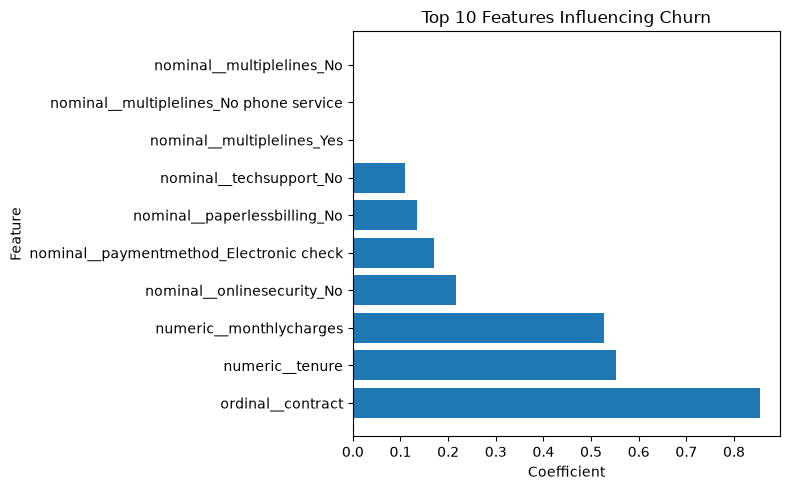

In [52]:

plt.figure(figsize=(8, 5))

plt.barh(
    top_10_features["Feature"],
    top_10_features["Importance"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Churn")

plt.tight_layout()
plt.show()

# Feature Importance Insights

* **Contract:** The strongest overall feature. Longer-term contracts are strongly associated with lower churn risk.
* **Tenure:** The second most important feature. Customers with a longer tenure are generally less likely to churn.
* **Monthly Charges:** Exerts a strong positive effect. Higher monthly charges correspond directly with a higher risk of churn.
* **Online Security = No:** Highly associated with an increased risk of customer churn.
* **Electronic Check:** This payment method is heavily linked with a higher churn risk.
* **Tech Support = No:** Contributes a smaller positive effect, but remains an active driver in predicting churn.
* **Multiple Lines:** Offers almost zero contribution to this model because its calculated coefficients are close to zero.


# Final Business Insights

## Model Performance
- The tuned Logistic Regression model achieved **82.1% recall**, meaning it identifies most customers who actually churn.
- The model achieved **83.1% ROC-AUC**, showing good ability to distinguish between churn and non-churn customers.
- Precision is **48.8%**, so some customers predicted as churners may not actually churn.
- The model is suitable when the business wants to **prioritize finding potential churners rather than maximizing accuracy**.

## Key Churn Drivers
- **Contract:** Month-to-month customers have a higher risk of churn, making contract type the strongest feature.
- **Tenure:** Customers with shorter tenure are more likely to churn.
- **Monthly Charges:** Customers with higher monthly charges show higher churn risk.
- **Online Security:** Customers without online security are more likely to churn.
- **Payment Method:** Customers using electronic check show higher churn risk.
- **Tech Support:** Customers without technical support have slightly higher churn risk.

## Business Recommendations
- Encourage high-risk month-to-month customers to move to longer-term contracts.
- Provide better onboarding and support for new customers with low tenure.
- Review pricing and plans for customers with high monthly charges.
- Promote online security and technical support services.
- Investigate the higher churn associated with electronic-check payments.

## Next Steps
- Tune the **classification threshold** to find a better balance between recall and precision.
- Compare **class weighting, oversampling, and undersampling** approaches.
- Perform further hyperparameter tuning and cross-validation.
- Use **SHAP explanations for individual customers** to understand their specific churn drivers.
- Integrate the ML model with a **GenAI retention system** to recommend personalized retention actions.

## Overall Conclusion

The analysis shows that **contract type, tenure, and monthly charges are the major factors associated with customer churn**. The tuned model provides strong churn detection, and the predictions can be further used with SHAP and GenAI to create personalized customer retention strategies.

In [56]:
import joblib

model_artifact = {
    "model": best_lr,
    "preprocessor": preprocessor,
    "threshold": 0.5,
    "model_name": "Logistic Regression",
    "model_version": "1.0"
}

joblib.dump(
    model_artifact,
    r"D:\Mine\telecom-churn\churn_logistic_regression.joblib"
)

['D:\\Mine\\telecom-churn\\churn_logistic_regression.joblib']

In [57]:
print(preprocessor.feature_names_in_)

['seniorcitizen' 'partner' 'dependents' 'tenure' 'multiplelines'
 'internetservice' 'onlinesecurity' 'onlinebackup' 'deviceprotection'
 'techsupport' 'streamingtv' 'streamingmovies' 'contract'
 'paperlessbilling' 'paymentmethod' 'monthlycharges' 'totalcharges']


In [58]:
shap_background = X_train_processed[
    :100
]

In [60]:
import joblib

model_artifact = {

    "model": best_lr,

    "preprocessor": preprocessor,

    "shap_background": shap_background,

    "threshold": 0.5,

    "model_name": "Logistic Regression",

    "model_version": "1.0"
}

joblib.dump(
    model_artifact,
    r"D:\Mine\telecom-churn\churn_logistic_regression.joblib"
)

['D:\\Mine\\telecom-churn\\churn_logistic_regression.joblib']

In [61]:
artifact = joblib.load(
    r"D:\Mine\telecom-churn\churn_logistic_regression.joblib"
)

print(artifact.keys())

dict_keys(['model', 'preprocessor', 'shap_background', 'threshold', 'model_name', 'model_version'])
